# 03 — Splits, Protótipo & Normalização

**Objetivo:** Dividir `base_features_tt` em treino/teste (70/30), aplicar protótipo de
desligados (SPEC §4.2), adicionar `val` temporal de `base_features_val`, e salvar todos os artefatos.

**Referência SPEC:** Seções 0.6, 4.2, 5, 10

---

| Entrada | Descrição |
|---|---|
| `data/gold/base_features_tt.parquet` | Base ML-ready — período Jan/2024–Mai/2025 |
| `data/gold/base_features_val.parquet` | Base ML-ready — validação temporal Jun–Ago/2025 |

| Saída | Descrição |
|---|---|
| `data/processed/splits/{grupo}/train.parquet` | 70% dos IDs — treino (com protótipo) |
| `data/processed/splits/{grupo}/test.parquet` | 30% dos IDs — teste (com protótipo) |
| `data/processed/splits/{grupo}/val.parquet` | Validação temporal (Jun–Ago/2025) |
| `data/processed/splits/{grupo}/scaler_cols.json` | Lista de colunas escalonadas |
| `models/{grupo}/standard_scaler.joblib` | Scaler fitado no treino |

**Invariantes garantidos:**
- Um mesmo colaborador não aparece em mais de um split (train/test) ✓
- Scaler fitado **apenas** no treino — sem data leakage ✓
- Protótipo aplicado **após** o split (evita leakage temporal) ✓
- Val é temporal: período diferente de train/test, selecionada em 01_ingest ✓


## 1 · Setup & Configuração

In [55]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-04-10 18:38


In [56]:
# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT   = Path.cwd().parent
DATA_GOLD      = PROJECT_ROOT / "data" / "gold"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_SPLITS    = DATA_PROCESSED / "splits"
MODELS         = PROJECT_ROOT / "models"
REPORTS        = PROJECT_ROOT / "reports"

# ── Grupos operacionais ───────────────────────────────────────
GRUPOS    = ["Vendas", "Transporte", "Fábrica"]
COL_GRUPO = "ds_grupo"

# ── Parâmetros SPEC §5 ────────────────────────────────────────
# Val é temporal (base_features_val) — não faz parte do split TT.
# 03_splits divide apenas TT em 70/30.
PROP_TRAIN      = 0.70   # 70% dos IDs → treino
PROP_TEST       = 0.30   # 30% dos IDs → teste  (val vem de base_features_val)
JANELA_PREDICAO = 4      # K para o protótipo de desligados (SPEC §4.2)

RNG_SEED = 42

COL_ID   = "id_colaborador"
COL_DATA = "dt_mes_ano"

# Heurística para classificar features em estáveis vs comportamentais
KEYWORDS_ESTAVEIS = ["salario", "tempo_empresa", "idade", "pib", "desemprego",
                     "custo_vida", "base_pay", "economico"]

print(f"Splits TT: {PROP_TRAIN:.0%} treino / {PROP_TEST:.0%} teste")
print(f"Val      : temporal (base_features_val)")
print(f"Protótipo: K={JANELA_PREDICAO} meses")
print(f"Seed     : {RNG_SEED}")
print(f"Grupos   : {GRUPOS}")


Splits TT: 70% treino / 30% teste
Val      : temporal (base_features_val)
Protótipo: K=4 meses
Seed     : 42
Grupos   : ['Vendas', 'Transporte', 'Fábrica']


## 2 · Funções Auxiliares

In [57]:

# ════════════════════════════════════════════════════════════════
# Protótipo de desligados — SPEC §4.2  [COMENTADO — ver medoide abaixo]
# Seleção iterativa de ativos — SPEC §4.3
# Aplicado APÓS o split (evita leakage temporal).
# ════════════════════════════════════════════════════════════════

# ── Parâmetros de seleção de ativos ──────────────────────────
KEYWORDS_MONOTON = ("tempo_empresa", "idade")  # excluídas da distância (monotônicas crescentes)
GAP_MIN_ATIV     = 3     # gap mínimo em meses entre registros consecutivos selecionados
GAP_MAX_ATIV     = 7     # gap máximo em meses
CORR_EPS         = 0.05  # floor mínimo de |cor(feature, target)| como peso


def _calcular_slope(valores):
    """Coeficiente angular de regressão linear simples sobre valores sequenciais."""
    v = valores.dropna().values.astype(float)
    if len(v) < 2:
        return 0.0
    x = np.arange(len(v))
    x_mean, y_mean = x.mean(), v.mean()
    num = ((x - x_mean) * (v - y_mean)).sum()
    den = ((x - x_mean) ** 2).sum()
    return num / den if den > 0 else 0.0


def _subsamplear_ativos(df_ativ, col_id, col_data, feature_cols_dist,
                         corr_weights, gap_min=GAP_MIN_ATIV, gap_max=GAP_MAX_ATIV,
                         eps=CORR_EPS):
    """
    Seleção iterativa de registros de ativos por máxima distância ponderada.

    Para cada colaborador ativo:
      1. Selecionar o primeiro registro (cronológico) — âncora inicial.
      2. Na janela [anchor + gap_min, anchor + gap_max] meses, selecionar
         o registro com maior distância ponderada da âncora atual.
      3. O registro selecionado vira a nova âncora; repetir até não haver candidatos.

    Distância ponderada (escala normalizada):
        d = sqrt( Σ_f  w_f · ((x_f^cand − x_f^anchor) / σ_f)² )
        w_f = max(|cor(f, target)|, eps)   -- calculado no treino antes do subsampling
        σ_f = std(f) no grupo              -- normalização de escala
    """
    feat_std = df_ativ[feature_cols_dist].std(ddof=1).replace(0, 1).values
    w        = corr_weights.reindex(feature_cols_dist).fillna(0.0).clip(lower=eps).values

    result_parts = []
    for _, grp in df_ativ.groupby(col_id, sort=False):
        grp = grp.sort_values(col_data).reset_index(drop=True)
        selected = [0]
        anchor   = 0

        while True:
            anchor_date = grp.loc[anchor, col_data]
            min_d = anchor_date + pd.DateOffset(months=gap_min)
            max_d = anchor_date + pd.DateOffset(months=gap_max)

            cands = grp[
                (grp[col_data] >= min_d) &
                (grp[col_data] <= max_d) &
                (~grp.index.isin(selected))
            ]
            if cands.empty:
                break

            anchor_vals = grp.loc[anchor, feature_cols_dist].to_numpy(dtype=float)
            cand_vals   = cands[feature_cols_dist].to_numpy(dtype=float)
            np.nan_to_num(anchor_vals, copy=False)
            np.nan_to_num(cand_vals,   copy=False)

            diffs = (cand_vals - anchor_vals) / feat_std
            dists = np.sqrt((w * diffs ** 2).sum(axis=1))

            best = cands.index[np.argmax(dists)]
            selected.append(best)
            anchor = best

        result_parts.append(grp.loc[selected])

    if not result_parts:
        return df_ativ.iloc[0:0].copy()
    return pd.concat(result_parts, ignore_index=True)


def construir_proto_e_mesclar(df_raw, col_id, col_data, col_target,
                               cols_est, cols_comport, cols_cat,
                               extremos_bin, K=4,
                               corr_weights=None, feature_cols_dist=None,
                               gap_min_ativ=GAP_MIN_ATIV, gap_max_ativ=GAP_MAX_ATIV,
                               use_medoid=True):
    """
    Seleciona representante(s) dos K=4 registros mais recentes de cada desligado
    e aplica seleção iterativa por máxima distância ponderada aos ativos.

    use_medoid=True  (padrão):
      Seleciona o medoide dos K registros mais recentes por ID positivo —
      o registro real mais central (menor soma de distâncias euclidianas).
      slope_cols = [] (sem features de tendência).

    use_medoid=False (teste):
      Usa TODOS os K registros mais recentes por ID positivo, sem agregar.
      Permite avaliar se a multiplicidade de registros por ID ajuda o modelo.

    ── PROTÓTIPO SINTÉTICO [COMENTADO — manter para referência] ──────────────
    A versão anterior criava uma linha sintética por ID positivo:
      - features estáveis       → último valor da janela K
      - features comportamentais → média da janela + slope (tendência linear)
      - features categóricas     → último valor (ou extremo se tocou min/max global)
    Vantagem: captura tendência temporal via slope.
    Desvantagem: cria observações não-reais; val/produção não passam pelo mesmo
    processo → distribuição de probabilidades incompatível entre splits.

    # prototipos = []
    # for id_colab, grp in df_desl.groupby(col_id):
    #     grp    = grp.sort_values(col_data)
    #     janela = grp.tail(K)
    #     ultimo = janela.iloc[-1]
    #
    #     proto = {col_id: id_colab, col_target: 1}
    #     for c in meta_set:
    #         if c in ultimo.index:
    #             proto[c] = ultimo[c]
    #     for c in cols_est:
    #         if c in janela.columns:
    #             proto[c] = ultimo[c]
    #     for c in cols_comport:
    #         if c in janela.columns:
    #             vals = pd.to_numeric(janela[c], errors="coerce")
    #             proto[c] = vals.mean()
    #             proto[f"{c}_slope_{K}"] = _calcular_slope(vals)
    #     for c in cols_cat:
    #         if c not in janela.columns:
    #             continue
    #         if c in extremos_bin:
    #             vals_c = pd.to_numeric(janela[c], errors="coerce").dropna()
    #             v_min, v_max = extremos_bin[c]["min"], extremos_bin[c]["max"]
    #             if len(vals_c) > 0 and (vals_c == v_min).any():
    #                 proto[c] = v_min
    #             elif len(vals_c) > 0 and (vals_c == v_max).any():
    #                 proto[c] = v_max
    #             else:
    #                 proto[c] = ultimo[c]
    #         else:
    #             proto[c] = ultimo[c]
    #     prototipos.append(proto)
    #
    # df_proto   = pd.DataFrame(prototipos)
    # slope_cols = [c for c in df_proto.columns if "_slope_" in c]
    # ── FIM PROTÓTIPO SINTÉTICO ───────────────────────────────────────────────
    """
    df_desl = df_raw[df_raw[col_target] == 1].copy()
    df_ativ = df_raw[df_raw[col_target] == 0].copy()

    meta_set = {col_id, col_data, col_target}
    for c in df_raw.columns:
        if c.startswith("fg_demitido_voluntario") or c in ("ds_grupo", "agrupamento_final"):
            meta_set.add(c)

    slope_cols = []  # sem slope sintético em ambos os modos

    if use_medoid:
        # ── Medoide: selecionar o registro mais central dos K mais recentes ──
        # Features usadas no cálculo de distância = todas as numéricas disponíveis
        # (normaliza cada feature pela std do grupo inteiro para escala comparável)
        _all_num = [c for c in df_raw.columns
                    if c not in meta_set and pd.api.types.is_numeric_dtype(df_raw[c])]
        _feat_std = df_raw[_all_num].std(ddof=1).replace(0, 1).values

        medoides = []
        for id_colab, grp in df_desl.groupby(col_id):
            grp    = grp.sort_values(col_data).reset_index(drop=True)
            janela = grp.tail(K).reset_index(drop=True)
            n      = len(janela)

            if n == 1:
                medoides.append(janela.iloc[0])
                continue

            vals = janela[_all_num].fillna(0).to_numpy(dtype=float) / _feat_std
            soma_dist = np.array([
                sum(np.linalg.norm(vals[i] - vals[j]) for j in range(n) if j != i)
                for i in range(n)
            ])
            medoides.append(janela.iloc[int(np.argmin(soma_dist))])

        if not medoides:
            return df_ativ.copy(), slope_cols

        df_proto = pd.DataFrame(medoides)

    else:
        # ── Sem medoide: todos os K registros mais recentes por ID positivo ──
        partes = []
        for id_colab, grp in df_desl.groupby(col_id):
            grp = grp.sort_values(col_data)
            partes.append(grp.tail(K))

        if not partes:
            return df_ativ.copy(), slope_cols

        df_proto = pd.concat(partes, ignore_index=True)

    # ── Seleção iterativa de ativos por máxima distância ponderada ────────────
    if corr_weights is not None and feature_cols_dist is not None:
        df_ativ = _subsamplear_ativos(
            df_ativ, col_id, col_data, feature_cols_dist,
            corr_weights, gap_min=gap_min_ativ, gap_max=gap_max_ativ,
        )

    # Alinhar colunas entre protótipos e ativos
    cols_comuns = sorted(set(df_proto.columns) & set(df_ativ.columns))
    result = pd.concat([df_proto[cols_comuns], df_ativ[cols_comuns]], ignore_index=True)
    return result, slope_cols


print("✓ Funções definidas  |  use_medoid suportado (True=medoide / False=todos os K registros)")


✓ Funções definidas  |  use_medoid suportado (True=medoide / False=todos os K registros)


Features usadas no cálculo de distância: 155

=== Vendas (1,604 IDs positivos) ===
  Mês 1 (pos mais antigo      ):   277   17.3%  ████████
  Mês 2 (pos intermediário    ):   553   34.5%  █████████████████
  Mês 3 (pos intermediário    ):   746   46.5%  ███████████████████████
  Mês 4 (pos mais recente     ):    28    1.7%  
  p50 posição = 2.0  |  média = 2.33

=== Transporte (2,409 IDs positivos) ===
  Mês 1 (pos mais antigo      ):   517   21.5%  ██████████
  Mês 2 (pos intermediário    ):   786   32.6%  ████████████████
  Mês 3 (pos intermediário    ): 1,074   44.6%  ██████████████████████
  Mês 4 (pos mais recente     ):    32    1.3%  
  p50 posição = 2.0  |  média = 2.26

=== Fábrica (1,012 IDs positivos) ===
  Mês 1 (pos mais antigo      ):   226   22.3%  ███████████
  Mês 2 (pos intermediário    ):   353   34.9%  █████████████████
  Mês 3 (pos intermediário    ):   419   41.4%  ████████████████████
  Mês 4 (pos mais recente     ):    14    1.4%  
  p50 posição = 2.0  |  média 

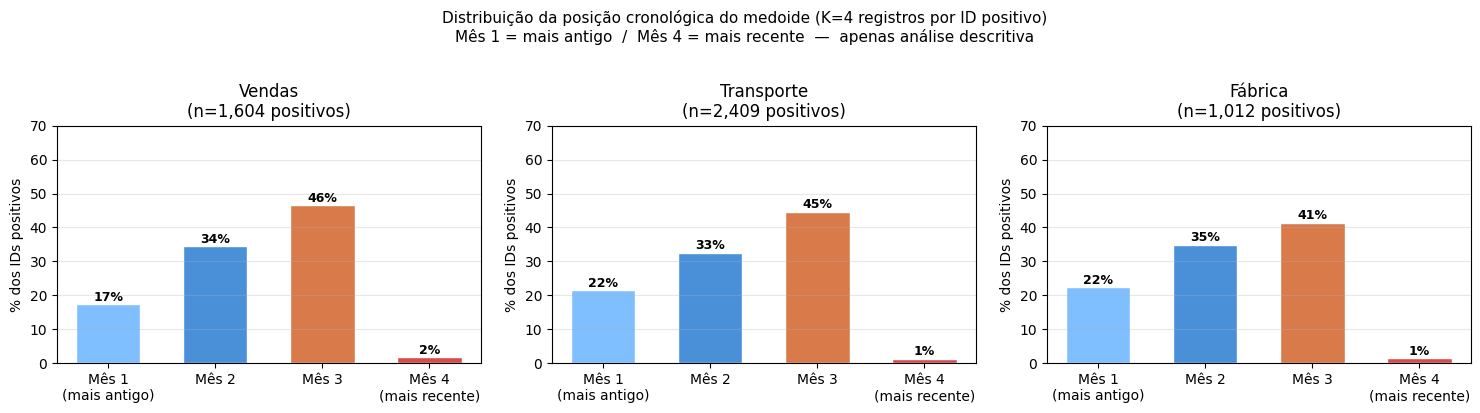

In [58]:

# ════════════════════════════════════════════════════════════════
# ANÁLISE DESCRITIVA — Seleção por medoide (sem alterar pipeline)
# ════════════════════════════════════════════════════════════════
# Para cada desligado, a janela K=4 mais recente contém 4 registros.
# A ideia do "mês mais representativo" é o medoide:
#   o registro cujo vetor de features tem a menor SOMA de distâncias
#   aos outros 3 registros (posição mais central dos 4).
#
# Aqui calculamos, para cada ID positivo, qual posição cronológica
# (1=mais antigo, 4=mais recente) seria o medoide — e reportamos
# a distribuição resultante por grupo.
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_DATA_GOLD = Path.cwd().parent / "data" / "gold"
_COL_ID     = "id_colaborador"
_COL_DATA   = "dt_mes_ano"
_COL_TARGET = "fg_demitido_voluntario_4m"
_COL_GRUPO  = "ds_grupo"
_K          = 4

df_tt_an = pd.read_parquet(_DATA_GOLD / "base_features_tt.parquet")
df_tt_an[_COL_DATA] = pd.to_datetime(df_tt_an[_COL_DATA])
df_tt_an[_COL_ID]   = df_tt_an[_COL_ID].astype(str)

# Features numéricas contínuas (peso = o que o modelo usa)
_meta_an  = {_COL_ID, _COL_DATA, _COL_TARGET, _COL_GRUPO}
_meta_an |= {c for c in df_tt_an.columns if c.startswith("fg_demitido_voluntario")}
_feat_an  = [c for c in df_tt_an.columns
             if c not in _meta_an and pd.api.types.is_numeric_dtype(df_tt_an[c])]

print(f"Features usadas no cálculo de distância: {len(_feat_an)}")
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, grupo in zip(axes, ["Vendas", "Transporte", "Fábrica"]):
    df_g   = df_tt_an[df_tt_an[_COL_GRUPO] == grupo].copy()
    desl_g = df_g[df_g[_COL_TARGET] == 1]

    posicoes = []  # posição (1..K) escolhida para cada ID

    for id_colab, grp in desl_g.groupby(_COL_ID):
        grp    = grp.sort_values(_COL_DATA).reset_index(drop=True)
        janela = grp.tail(_K).reset_index(drop=True)
        n      = len(janela)

        if n < 2:
            posicoes.append(1)
            continue

        # Matriz de features normalizada pela std do grupo
        vals = janela[_feat_an].fillna(0).to_numpy(dtype=float)
        std  = df_g[_feat_an].std(ddof=1).fillna(1).replace(0, 1).to_numpy(dtype=float)
        vals_norm = vals / std

        # Distância euclidiana entre cada par de registros
        # medoide = registro com menor soma de distâncias aos outros
        soma_dist = np.zeros(n)
        for i in range(n):
            for j in range(n):
                if i != j:
                    soma_dist[i] += np.linalg.norm(vals_norm[i] - vals_norm[j])

        medoide_pos  = int(np.argmin(soma_dist))   # 0-based dentro da janela
        # Posição cronológica: janela começa no registro K-n (dentro dos últimos K)
        # posição 1 = mais antigo, 4 = mais recente
        posicao_crono = (_K - n) + medoide_pos + 1   # 1-indexed
        posicoes.append(posicao_crono)

    s = pd.Series(posicoes)
    dist = s.value_counts().sort_index()
    pct  = (dist / dist.sum() * 100).round(1)

    print(f"=== {grupo} ({len(posicoes):,} IDs positivos) ===")
    for pos in range(1, _K + 1):
        bar = "█" * int(pct.get(pos, 0) / 2)
        print(f"  Mês {pos} (pos {'mais antigo' if pos==1 else ('mais recente' if pos==4 else 'intermediário'):<17}): "
              f"{int(dist.get(pos,0)):>5,}  {pct.get(pos,0):>5.1f}%  {bar}")
    print(f"  p50 posição = {s.median():.1f}  |  média = {s.mean():.2f}")

    # Histograma
    ax.bar([1, 2, 3, 4],
           [pct.get(i, 0) for i in [1, 2, 3, 4]],
           color=["#7fbfff", "#4a90d9", "#d97a4a", "#d94a4a"],
           edgecolor="white", width=0.6)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Mês 1\n(mais antigo)", "Mês 2", "Mês 3", "Mês 4\n(mais recente)"])
    ax.set_ylabel("% dos IDs positivos")
    ax.set_ylim(0, 70)
    ax.set_title(f"{grupo}\n(n={len(posicoes):,} positivos)")
    ax.grid(axis="y", alpha=0.3)
    for xi, yi in enumerate([pct.get(i, 0) for i in [1, 2, 3, 4]], start=1):
        ax.text(xi, yi + 1, f"{yi:.0f}%", ha="center", fontsize=9, fontweight="bold")
    print()

plt.suptitle(
    "Distribuição da posição cronológica do medoide (K=4 registros por ID positivo)\n"
    "Mês 1 = mais antigo  /  Mês 4 = mais recente  —  apenas análise descritiva",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()
plt.close()


In [ ]:

# ── Carregar bases (uma vez, reutilizado entre grupos) ────────
print("Carregando bases ML-ready...")
df_tt_full  = pd.read_parquet(DATA_GOLD / "base_features_tt.parquet")
df_val_full = pd.read_parquet(DATA_GOLD / "base_features_val.parquet")

df_tt_full[COL_DATA]  = pd.to_datetime(df_tt_full[COL_DATA])
df_val_full[COL_DATA] = pd.to_datetime(df_val_full[COL_DATA])
df_tt_full[COL_ID]    = df_tt_full[COL_ID].astype(str)
df_val_full[COL_ID]   = df_val_full[COL_ID].astype(str)

print(f"  base_features_tt : {df_tt_full.shape[0]:,} × {df_tt_full.shape[1]}  "
      f"| grupos={df_tt_full[COL_GRUPO].value_counts().to_dict()}")
print(f"  base_features_val: {df_val_full.shape[0]:,} × {df_val_full.shape[1]}  "
      f"| grupos={df_val_full[COL_GRUPO].value_counts().to_dict()}")

# ── Controle: usar medoide ou todos os K registros ────────────
USE_MEDOID = False   # True = medoide (1 registro por ID positivo)
                     # False = todos os K registros mais recentes por ID positivo
print(f"\n  USE_MEDOID = {USE_MEDOID}")

# ── Pipeline de splits por grupo ─────────────────────────────
for GRUPO in GRUPOS:
    print(f"\n{'='*62}")
    print(f"GRUPO: {GRUPO}")
    print('='*62)

    grupo_splits = DATA_SPLITS / GRUPO
    grupo_models = MODELS / GRUPO
    grupo_splits.mkdir(parents=True, exist_ok=True)
    grupo_models.mkdir(parents=True, exist_ok=True)

    # ── Filtrar por grupo ─────────────────────────────────────
    df_tt  = df_tt_full[df_tt_full[COL_GRUPO] == GRUPO].copy().reset_index(drop=True)
    df_val = df_val_full[df_val_full[COL_GRUPO] == GRUPO].copy().reset_index(drop=True)

    # Detectar target
    targets_str = [c for c in df_tt.columns if c.startswith("fg_demitido_voluntario")]
    if not targets_str:
        print(f"  ⚠ Target não encontrado — pulando {GRUPO}")
        continue
    COL_TARGET = targets_str[0]

    print(f"  TT : {df_tt.shape[0]:,} reg | {df_tt[COL_ID].nunique():,} IDs | "
          f"turnover: {df_tt[COL_TARGET].mean():.2%}")
    print(f"  Val: {df_val.shape[0]:,} reg | {df_val[COL_ID].nunique():,} IDs | "
          f"turnover: {df_val[COL_TARGET].mean():.2%}")

    # ── Classificar features para o medoide ──────────────────
    META = {COL_ID, COL_DATA, COL_TARGET}
    META.update(c for c in df_tt.columns if c.startswith("fg_demitido_voluntario"))
    for col_meta in ["ds_grupo", "agrupamento_final"]:
        if col_meta in df_tt.columns:
            META.add(col_meta)

    FEATURE_COLS = [c for c in df_tt.columns if c not in META]

    bin_ord_cols = [c for c in FEATURE_COLS
                    if c.endswith("_bin") and pd.api.types.is_numeric_dtype(df_tt[c])]
    ohe_bin_cols = [c for c in FEATURE_COLS
                    if pd.api.types.is_numeric_dtype(df_tt[c])
                    and df_tt[c].nunique(dropna=True) <= 2
                    and not c.endswith("_bin")]
    cat_cols = bin_ord_cols + ohe_bin_cols

    num_feats   = [c for c in FEATURE_COLS
                   if pd.api.types.is_numeric_dtype(df_tt[c]) and c not in cat_cols]
    num_est     = [c for c in num_feats if any(kw in c.lower() for kw in KEYWORDS_ESTAVEIS)]
    num_comport = [c for c in num_feats if c not in num_est]

    extremos_bin = {c: {"min": df_tt[c].min(), "max": df_tt[c].max()} for c in bin_ord_cols}

    # ── Split 70/30 por ID (estratificado pelo target) ────────
    id_target = (
        df_tt.groupby(COL_ID)[COL_TARGET]
        .max().reset_index()
        .rename(columns={COL_TARGET: "turnover_flag"})
    )

    ids_train, ids_test = train_test_split(
        id_target[COL_ID].values,
        test_size=PROP_TEST,
        stratify=id_target["turnover_flag"].values,
        random_state=RNG_SEED,
    )

    assert set(ids_train).isdisjoint(set(ids_test)), f"[{GRUPO}] Vazamento train↔test!"

    df_train_raw = df_tt[df_tt[COL_ID].isin(ids_train)].copy()
    df_test_raw  = df_tt[df_tt[COL_ID].isin(ids_test)].copy()

    print(f"\n  Split pré-medoide:")
    print(f"    Treino: {df_train_raw[COL_ID].nunique():,} IDs | {len(df_train_raw):,} reg")
    print(f"    Teste : {df_test_raw[COL_ID].nunique():,} IDs | {len(df_test_raw):,} reg")

    # ── Pesos de correlação para seleção iterativa de ativos ──
    # Calculados no painel completo de treino (antes do subsampling).
    # Features monotônicas crescentes (tempo_empresa, idade) são excluídas.
    feature_cols_dist = [
        c for c in num_feats + cat_cols
        if not any(kw in c.lower() for kw in KEYWORDS_MONOTON)
    ]
    corr_with_target = (
        df_train_raw[feature_cols_dist + [COL_TARGET]]
        .corr()[COL_TARGET]
        .abs()
        .drop(COL_TARGET)
    )
    n_above_eps = int((corr_with_target >= CORR_EPS).sum())
    print(f"\n  Correlação c/ target: {len(feature_cols_dist)} features analisadas  |  "
          f"cor≥{CORR_EPS}: {n_above_eps}  |  "
          f"top-3: {corr_with_target.nlargest(3).index.tolist()}")

    # ── Aplicar medoide ou todos os K registros (pós-split) ───
    df_train, slope_cols = construir_proto_e_mesclar(
        df_train_raw, COL_ID, COL_DATA, COL_TARGET,
        num_est, num_comport, cat_cols, extremos_bin, K=JANELA_PREDICAO,
        corr_weights=corr_with_target, feature_cols_dist=feature_cols_dist,
        use_medoid=USE_MEDOID,
    )
    df_test, _ = construir_proto_e_mesclar(
        df_test_raw, COL_ID, COL_DATA, COL_TARGET,
        num_est, num_comport, cat_cols, extremos_bin, K=JANELA_PREDICAO,
        corr_weights=corr_with_target, feature_cols_dist=feature_cols_dist,
        use_medoid=USE_MEDOID,
    )

    # Val: NÃO passa por construir_proto_e_mesclar — base pura (snapshots mensais reais)
    # Apenas scaler.transform será aplicado abaixo. Isso garante que a distribuição
    # de target (~15%) e de negativos (~2,8 rows/ID) reflita a população real.

    modo_label = "medoide" if USE_MEDOID else f"todos os K={JANELA_PREDICAO} registros"
    print(f"\n  Após seleção ({modo_label}):")
    print(f"    Treino: {df_train[COL_ID].nunique():,} IDs | {len(df_train):,} reg | "
          f"turnover: {df_train[COL_TARGET].mean():.2%}")
    print(f"    Teste : {df_test[COL_ID].nunique():,} IDs | {len(df_test):,} reg | "
          f"turnover: {df_test[COL_TARGET].mean():.2%}")
    print(f"    Val   : {df_val[COL_ID].nunique():,} IDs | {len(df_val):,} reg | "
          f"turnover: {df_val[COL_TARGET].mean():.2%}  [pura — sem construir]")

    # ── StandardScaler nas contínuas (fit no treino) ──────────
    META_SCALE = {COL_ID, COL_DATA, COL_TARGET}
    META_SCALE.update(c for c in df_train.columns if c.startswith("fg_demitido_voluntario"))
    for col_meta in ["ds_grupo", "agrupamento_final"]:
        if col_meta in df_train.columns:
            META_SCALE.add(col_meta)

    scale_cols = [
        c for c in df_train.columns
        if c not in META_SCALE
        and pd.api.types.is_numeric_dtype(df_train[c])
        and not c.endswith("_bin")
        and df_train[c].nunique(dropna=True) > 2
    ]

    scaler = StandardScaler()
    scaler.fit(df_train[scale_cols])
    df_train[scale_cols] = scaler.transform(df_train[scale_cols])
    df_test[scale_cols]  = scaler.transform(df_test[scale_cols])

    # Val: transformar apenas as colunas em comum com scale_cols
    scale_cols_val = [c for c in scale_cols if c in df_val.columns]
    df_val[scale_cols_val] = scaler.transform(df_val[scale_cols_val])

    tv_val = df_val[COL_TARGET].mean() if COL_TARGET in df_val.columns else float("nan")
    print(f"\n  Scaler: {len(scale_cols)} colunas escalonadas")
    print(f"  Val: {df_val[COL_ID].nunique():,} IDs | {len(df_val):,} reg | "
          f"turnover: {tv_val:.2%}")

    # ── Salvar splits e artefatos ─────────────────────────────
    paths = {
        "train": grupo_splits / "train.parquet",
        "test" : grupo_splits / "test.parquet",
        "val"  : grupo_splits / "val.parquet",
    }
    df_train.to_parquet(paths["train"], index=False)
    df_test.to_parquet(paths["test"],   index=False)
    df_val.to_parquet(paths["val"],     index=False)

    scaler_path     = grupo_models / "standard_scaler.joblib"
    scale_cols_path = grupo_splits / "scaler_cols.json"

    joblib.dump(scaler, scaler_path)
    with open(scale_cols_path, "w", encoding="utf-8") as f:
        json.dump({
            "scale_cols"  : scale_cols,
            "slope_cols"  : slope_cols,
            "col_id"      : COL_ID,
            "col_target"  : COL_TARGET,
            "col_data"    : COL_DATA,
            "n_scale_cols": len(scale_cols),
            "grupo"       : GRUPO,
            "use_medoid"  : USE_MEDOID,
        }, f, indent=2, ensure_ascii=False)

    print(f"\n  Outputs em splits/{GRUPO}/:")
    for nome, p in paths.items():
        mb = p.stat().st_size / 1e6
        print(f"    {nome:<6} → {p.name}  ({mb:.1f} MB)")
    print(f"    scaler_cols.json  |  standard_scaler.joblib → models/{GRUPO}/")

print(f"\n{'='*62}")
print(f"✓ Splits gerados para {len(GRUPOS)} grupos: {GRUPOS}")
print(f"  USE_MEDOID = {USE_MEDOID}")
print(f"{'='*62}")


Carregando bases ML-ready...
  base_features_tt : 116,307 × 159  | grupos={'Transporte': 53931, 'Vendas': 39546, 'Fábrica': 22830}
  base_features_val: 17,479 × 159  | grupos={'Transporte': 8166, 'Vendas': 5942, 'Fábrica': 3371}

  USE_MEDOID = False

GRUPO: Vendas
  TT : 39,546 reg | 3,872 IDs | turnover: 13.38%
  Val: 5,942 reg | 2,115 IDs | turnover: 15.01%

  Split pré-medoide:
    Treino: 2,710 IDs | 27,835 reg
    Teste : 1,162 IDs | 11,711 reg

  Correlação c/ target: 150 features analisadas  |  cor≥0.05: 39  |  top-3: ['vl_dias_menos_6_horas_med_3m', 'vl_dias_menos_6_horas_med_6m', 'vl_dias_menos_6_horas_med_3m_bin']

  Após seleção (todos os K=4 registros):
    Treino: 2,710 IDs | 9,843 reg | turnover: 37.81%
    Teste : 1,162 IDs | 4,128 reg | turnover: 38.03%
    Val   : 2,115 IDs | 2,669 reg | turnover: 33.42%

  Scaler: 100 colunas escalonadas
  Val: 2,115 IDs | 2,669 reg | turnover: 33.42%

  Outputs em splits/Vendas/:
    train  → train.parquet  (5.3 MB)
    test   → tes

## 3 · Split por ID Colaborador (SPEC §5)

**Regra obrigatória:** todos os registros de um colaborador vão para o mesmo conjunto.
O split é feito ao nível de `id_colaborador` e depois os registros são atribuídos conforme o split do ID.

**Estratificação:** pela taxa de turnover voluntário de cada colaborador
(se o colaborador tem) algum registro target=1 nas janelas analisadas).

In [60]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [61]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [62]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 4 · StandardScaler nas Contínuas (SPEC §10)

Escalonar apenas as features **contínuas** — sem escalonar:
- Colunas `_bin` (ordinais 1–5): já em escala ordinal interpretável
- Colunas OHE (binárias 0/1): qualquer coluna com ≤ 2 valores únicos
- Colunas de metadados: id, data, target

**O scaler é fitado exclusivamente no treino** e transformado em val e teste.

In [63]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [64]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 5 · Verificação Final dos Splits

In [65]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 6 · Salvar Splits e Artefatos

In [66]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [67]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [68]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [69]:

# Distribuição 0/1 por grupo × mês (pré-split, base_features_tt completa)
tbl = (
    df_tt_full
    .groupby([COL_GRUPO, COL_DATA, COL_TARGET])
    .size()
    .unstack(COL_TARGET, fill_value=0)
    .rename(columns={0: "neg", 1: "pos"})
    .assign(total=lambda d: d["neg"] + d["pos"],
            tx=lambda d: (d["pos"] / (d["neg"] + d["pos"]) * 100).round(1))
)

for grupo, sub in tbl.groupby(level=0):
    s = sub.droplevel(0)
    print(f"\n{grupo}  (neg_total={s['neg'].sum():,}  pos_total={s['pos'].sum():,}  tx_media={s['pos'].sum()/s['total'].sum()*100:.1f}%)")
    print(f"  {'mês':<12} {'neg':>7} {'pos':>6} {'total':>7} {'tx%':>6}")
    for mes, row in s.iterrows():
        print(f"  {str(mes):<12} {row['neg']:>7,} {row['pos']:>6,} {row['total']:>7,} {row['tx']:>5.1f}%")



Fábrica  (neg_total=19,617  pos_total=3,213  tx_media=14.1%)
  mês              neg    pos   total    tx%
  2024-01-01 00:00:00 1,348.0  197.0 1,545.0  12.8%
  2024-02-01 00:00:00 1,354.0  210.0 1,564.0  13.4%
  2024-03-01 00:00:00 1,334.0  247.0 1,581.0  15.6%
  2024-04-01 00:00:00 1,338.0  237.0 1,575.0  15.0%
  2024-05-01 00:00:00 1,199.0  204.0 1,403.0  14.5%
  2024-06-01 00:00:00 1,201.0  194.0 1,395.0  13.9%
  2024-07-01 00:00:00 1,170.0  199.0 1,369.0  14.5%
  2024-08-01 00:00:00 1,187.0  208.0 1,395.0  14.9%
  2024-09-01 00:00:00 1,051.0  169.0 1,220.0  13.9%
  2024-10-01 00:00:00 1,087.0  176.0 1,263.0  13.9%
  2024-11-01 00:00:00 1,095.0  146.0 1,241.0  11.8%
  2024-12-01 00:00:00 1,111.0  171.0 1,282.0  13.3%
  2025-01-01 00:00:00 1,036.0  158.0 1,194.0  13.2%
  2025-02-01 00:00:00 1,054.0  171.0 1,225.0  14.0%
  2025-03-01 00:00:00 1,076.0  154.0 1,230.0  12.5%
  2025-04-01 00:00:00 1,044.0  198.0 1,242.0  15.9%
  2025-05-01 00:00:00   932.0  174.0 1,106.0  15.7%

Transpor